# nb03 — рыночный breadth-kill-switch

Из nb02: просадку счёта делают **широкие риск-офф дни** (много монет падает разом), а не пачка стопов
одной монеты. Логичный ответ — **причинный breadth-фильтр**: гасить входы, когда за трейлинг-окно по
ВСЕЙ вселенной сработало слишком много дамп-событий (рынок в общем сливе).

**Правило (каузальное):** для каждого кандидата на вход в момент t считаем `dump_breadth(t)` = число
дамп-триггеров по всем символам за трейлинг-окно W (только прошлое). Если `≥ K` — глушим (жёстко:
пропуск; или мягко: режем размер). Breadth берём с ПОЛНОЙ сигнальной вселенной (состояние рынка,
независимо от того, что мы торгуем).

**Честное натяжение (урок оригинала dump-nb09):** дни высокого breadth — это ещё и **топ-прибыльные
дни отскока** (большой вымыв → большой bounce). Поэтому фильтр может резать edge вместо DD. Плюс из
nb02: самый большой дамп-день 2025-10-10 (319 событий) был для счёта +/−0 (хедж погасил), а плохой день
2025-02-03 — это тоже высокий breadth. Сможет ли фильтр отличить V-день от grind-дня? Проверяем.

In [1]:
import sys; sys.path.insert(0, ".")
from _engine import load_signals, build_book, run_dca, metrics, CST
from _lab import show
import numpy as np, pandas as pd

PUMP, DUMP = load_signals()
BOOK = build_book(PUMP, DUMP)

# breadth-опора = ВСЕ сырые триггеры по вселенной (состояние рынка)
all_dump = np.sort(DUMP["entry"].values.astype("datetime64[ns]"))
all_pump = np.sort(PUMP["entry"].values.astype("datetime64[ns]"))
def breadth_at(times, ref, W_min):
    W = np.timedelta64(W_min, "m"); t = times.astype("datetime64[ns]")
    return np.searchsorted(ref, t, side="right") - np.searchsorted(ref, t - W, side="left")

for W in (60, 240):
    db = breadth_at(BOOK["entry"].values, all_dump, W)
    BOOK[f"dumpbreadth{W}"] = db
print("dump-breadth на сделках книги:")
for W in (60,240):
    b=BOOK[f"dumpbreadth{W}"]; print(f"  W={W}m: median {b.median():.0f}  p90 {b.quantile(.9):.0f}  p99 {b.quantile(.99):.0f}  max {b.max()}")
print(f"BOOK {len(BOOK)} сделок")

dump-breadth на сделках книги:
  W=60m: median 0  p90 150  p99 188  max 191
  W=240m: median 1  p90 162  p99 279  max 314
BOOK 14509 сделок


## A. Жёсткий kill на дамп-breadth (глушим дамп-входы при breadth ≥ K)

Пампы не трогаем (они на риск-офф как раз хедж). Свип K для окна W=60м; движок — агрессивный 5/3.

In [2]:
def kill_dump(book, K, W=60):
    """ffrac: дамп-входы с breadth>=K зануляем (пропуск), остальное как обычно (agg 5/3)."""
    f = np.where(book["stream"].values=="pump", 0.05, 0.03).astype(float)
    blocked = (book["stream"].values=="dump") & (book[f"dumpbreadth{W}"].values >= K)
    f = f.copy(); f[blocked] = 0.0
    return f, blocked

rows=[]
for K in (60,90,120,150,180, None):
    if K is None:
        R=run_dca(BOOK,f_pump=0.05,f_dump=0.03); nb=0; bpnl=np.nan
    else:
        f,bl=kill_dump(BOOK,K); R=run_dca(BOOK,ffrac=f); nb=int(bl.sum()); bpnl=BOOK[bl].pnl.mean()*100
    m=metrics(R,f"K={K}"); m["blk_dump"]=nb; m["blk_mean"]=f"{bpnl:+.1f}%" if nb else "-"
    rows.append(m)
print("=== жёсткий kill на dump-breadth60, agg 5/3, полный период ===")
print(pd.DataFrame(rows)[["config","blk_dump","blk_mean","final","mult","Sharpe","Sortino","maxDD","worstday","worst","taken"]].to_string(index=False))

=== жёсткий kill на dump-breadth60, agg 5/3, полный период ===
config  blk_dump blk_mean   final mult Sharpe Sortino  maxDD worstday worst  taken
  K=60      2107    +8.6% $36,923 5.3x   2.85    2.68 -26.8%   -20.2%  -37%  10140
  K=90      1796    +8.8% $39,740 5.7x   2.83    2.81 -27.0%   -20.4%  -37%  10166
 K=120      1266   +10.1% $41,254 5.9x   2.89    2.89 -26.9%   -20.2%  -37%  10177
 K=150       596   +15.1% $42,108 6.0x   2.96    3.08 -23.3%   -16.3%  -37%  10178
 K=180       132   +15.5% $43,610 6.2x   3.05    3.33 -21.1%   -13.8%  -37%  10179
K=None         0        - $43,738 6.2x   3.04    3.34 -21.1%   -13.8%  -37%  10179


### Смотрим числа (в ячейке): помог ли фильтр?

In [3]:
Roff=run_dca(BOOK,f_pump=0.05,f_dump=0.03)
def q(R):
    nav=R["nav"]; rr=nav.pct_change().dropna()
    return R["final"], rr.mean()/rr.std()*np.sqrt(365), (nav.values/np.maximum.accumulate(nav.values)-1).min()*100, nav.pct_change().min()*100
of=q(Roff)
print("жёсткий dump-kill vs выкл (agg 5/3):")
for K in (60,90,120,150):
    f,bl=kill_dump(BOOK,K); r=q(run_dca(BOOK,ffrac=f))
    print(f"  K={K:>3}: рост {r[0]/of[0]-1:+.0%} | Sharpe {r[1]:.2f} (Δ{r[1]-of[1]:+.2f}) | "
          f"maxDD {r[2]:+.1f}% (Δ{r[2]-of[2]:+.1f}pp) | худший день {r[3]:+.1f}% (выкл {of[3]:+.1f}%)")
print("экономика заблокированных дампов: если mean<0 — режем убыток (польза), если >0 — режем прибыль.")

жёсткий dump-kill vs выкл (agg 5/3):


  K= 60: рост -16% | Sharpe 2.85 (Δ-0.19) | maxDD -26.8% (Δ-5.8pp) | худший день -20.2% (выкл -13.8%)


  K= 90: рост -9% | Sharpe 2.83 (Δ-0.21) | maxDD -27.0% (Δ-5.9pp) | худший день -20.4% (выкл -13.8%)


  K=120: рост -6% | Sharpe 2.89 (Δ-0.15) | maxDD -26.9% (Δ-5.8pp) | худший день -20.2% (выкл -13.8%)
  K=150: рост -4% | Sharpe 2.96 (Δ-0.08) | maxDD -23.3% (Δ-2.3pp) | худший день -16.3% (выкл -13.8%)
экономика заблокированных дампов: если mean<0 — режем убыток (польза), если >0 — режем прибыль.


## B. Ключевая проверка: V-день vs grind-день (почему breadth плохо разделяет)

2025-10-10 (максимум дамп-breadth, для счёта ~0) против 2025-02-03 (худший день NAV). Считаем в ячейке
дневной pnl дамп-ноги и breadth на оба — фильтр видит одинаково высокий breadth, а исход разный.

In [4]:
bd = BOOK.assign(day=BOOK["entry"].dt.floor("D"))
for day in ("2025-10-10","2025-02-03","2024-04-12","2024-08-05"):
    d=pd.Timestamp(day); sub=bd[bd.day==d]
    dsub=sub[sub.stream=="dump"]; psub=sub[sub.stream=="pump"]
    print(f"{day}: dump-событий(book) {len(dsub)}  breadth60 median {sub.dumpbreadth60.median():.0f}  | "
          f"dump pnl mean {dsub.pnl.mean()*100:+.1f}% сумма {dsub.pnl.sum()*100:+.0f}%  | "
          f"pump pnl mean {psub.pnl.mean()*100 if len(psub) else 0:+.1f}%")
print("\n-> высокий breadth в оба дня, но dump-исход РАЗНЫЙ (V-отскок vs grind) -> одним breadth не отличить.")
# корреляция: breadth дня vs дневной pnl дамп-ноги
g=bd[bd.stream=="dump"].groupby("day").agg(bmed=("dumpbreadth60","median"), pnl=("pnl","mean"))
print(f"corr(dump-breadth дня, средний dump-pnl дня) = {g.bmed.corr(g.pnl):+.2f}  (около 0 = breadth НЕ предсказывает исход)")

2025-10-10: dump-событий(book) 240  breadth60 median 117  | dump pnl mean +23.5% сумма +5643%  | pump pnl mean -6.2%
2025-02-03: dump-событий(book) 162  breadth60 median 138  | dump pnl mean +7.8% сумма +1269%  | pump pnl mean -6.0%
2024-04-12: dump-событий(book) 217  breadth60 median 160  | dump pnl mean -2.0% сумма -435%  | pump pnl mean -1.9%
2024-08-05: dump-событий(book) 257  breadth60 median 104  | dump pnl mean +0.8% сумма +204%  | pump pnl mean -3.9%

-> высокий breadth в оба дня, но dump-исход РАЗНЫЙ (V-отскок vs grind) -> одним breadth не отличить.
corr(dump-breadth дня, средний dump-pnl дня) = +0.19  (около 0 = breadth НЕ предсказывает исход)


## C. Мягкий вариант: резать РАЗМЕР дампа ∝ 1/breadth (а не жёсткий пропуск)

In [5]:
def soft_dump(book, K, W=60, floor=0.25):
    """дамп-размер = 3% * clip(K/breadth, floor..1); памп без изменений."""
    f = np.where(book["stream"].values=="pump", 0.05, 0.03).astype(float)
    b = book[f"dumpbreadth{W}"].values.astype(float)
    scale = np.clip(K/np.maximum(b,1), floor, 1.0)
    dmask = book["stream"].values=="dump"; f=f.copy(); f[dmask]=0.03*scale[dmask]
    return f
rows=[]
for K in (60,90,120, None):
    if K is None: R=run_dca(BOOK,f_pump=0.05,f_dump=0.03)
    else: R=run_dca(BOOK,ffrac=soft_dump(BOOK,K))
    rows.append(metrics(R,f"soft K={K}"))
print("=== мягкий (размер дампа ∝ K/breadth, пол 25%), agg ===")
print(pd.DataFrame(rows)[["config","final","mult","Sharpe","Sortino","maxDD","worstday","worst"]].to_string(index=False))

=== мягкий (размер дампа ∝ K/breadth, пол 25%), agg ===
     config   final mult Sharpe Sortino  maxDD worstday worst
  soft K=60 $42,356 6.1x   3.01    3.20 -22.4%   -15.2%  -37%
  soft K=90 $43,207 6.2x   3.02    3.27 -21.9%   -14.7%  -37%
 soft K=120 $43,400 6.2x   3.03    3.30 -21.4%   -14.2%  -37%
soft K=None $43,738 6.2x   3.04    3.34 -21.1%   -13.8%  -37%


## D. Разворот, на который указали данные: гасить ПАМП на высоком дамп-breadth

Диагностика (B) показала: на широких риск-офф днях дамп-нога ВЫИГРЫВАЕТ (отскок), а **памп-нога теряет**
(−6%). Значит причинно правильнее глушить не дамп, а **памп-входы**, когда рынок в общем сливе. Проверяем
(риск оверфита: это уже вторая попытка на тех же данных — держим в уме).

In [6]:
def kill_pump(book, K, W=60):
    f = np.where(book["stream"].values=="pump", 0.05, 0.03).astype(float)
    bl = (book["stream"].values=="pump") & (book[f"dumpbreadth{W}"].values >= K)
    f=f.copy(); f[bl]=0.0; return f, bl
rows=[]
for K in (60,90,120,150,180, None):
    if K is None: R=run_dca(BOOK,f_pump=0.05,f_dump=0.03); nb=0; bp=np.nan
    else:
        f,bl=kill_pump(BOOK,K); R=run_dca(BOOK,ffrac=f); nb=int(bl.sum()); bp=BOOK[bl].pnl.mean()*100
    m=metrics(R,f"K={K}"); m["blk_pump"]=nb; m["blk_mean"]=f"{bp:+.1f}%" if nb else "-"
    rows.append(m)
print("=== гасим ПАМП при dump-breadth60>=K, agg 5/3 ===")
print(pd.DataFrame(rows)[["config","blk_pump","blk_mean","final","mult","Sharpe","Sortino","maxDD","worstday","worst"]].to_string(index=False))
print("\nэкономика заблокированных пампов (mean<0 = резали убыток = польза):")
for K in (60,90,120,150):
    f,bl=kill_pump(BOOK,K); r=q(run_dca(BOOK,ffrac=f))
    print(f"  K={K:>3}: blk {int(bl.sum()):4d}  blk-mean {BOOK[bl].pnl.mean()*100:+.1f}%  | рост {r[0]/of[0]-1:+.0%} "
          f"Sharpe {r[1]:.2f}(Δ{r[1]-of[1]:+.2f}) maxDD {r[2]:+.1f}%(Δ{r[2]-of[2]:+.1f}pp) худ.день {r[3]:+.1f}%")

=== гасим ПАМП при dump-breadth60>=K, agg 5/3 ===
config  blk_pump blk_mean   final mult Sharpe Sortino  maxDD worstday worst
  K=60      1171    -3.9% $43,714 6.2x   3.04    3.34 -21.1%   -13.8%  -37%
  K=90      1163    -3.9% $43,714 6.2x   3.04    3.34 -21.1%   -13.8%  -37%
 K=120      1014    -3.5% $43,745 6.2x   3.04    3.34 -21.1%   -13.8%  -37%
 K=150       975    -3.6% $43,687 6.2x   3.04    3.34 -21.1%   -13.8%  -37%
 K=180       162    -6.6% $43,738 6.2x   3.04    3.34 -21.1%   -13.8%  -37%
K=None         0        - $43,738 6.2x   3.04    3.34 -21.1%   -13.8%  -37%

экономика заблокированных пампов (mean<0 = резали убыток = польза):
  K= 60: blk 1171  blk-mean -3.9%  | рост -0% Sharpe 3.04(Δ-0.00) maxDD -21.1%(Δ-0.1pp) худ.день -13.8%


  K= 90: blk 1163  blk-mean -3.9%  | рост -0% Sharpe 3.04(Δ-0.00) maxDD -21.1%(Δ-0.1pp) худ.день -13.8%


  K=120: blk 1014  blk-mean -3.5%  | рост +0% Sharpe 3.04(Δ-0.00) maxDD -21.1%(Δ-0.1pp) худ.день -13.8%
  K=150: blk  975  blk-mean -3.6%  | рост -0% Sharpe 3.04(Δ-0.00) maxDD -21.1%(Δ-0.1pp) худ.день -13.8%


[saved] notebooks\pump_dump_v2\_out\v2_nb03_killswitch.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_v2/_out/v2_nb03_killswitch.png')

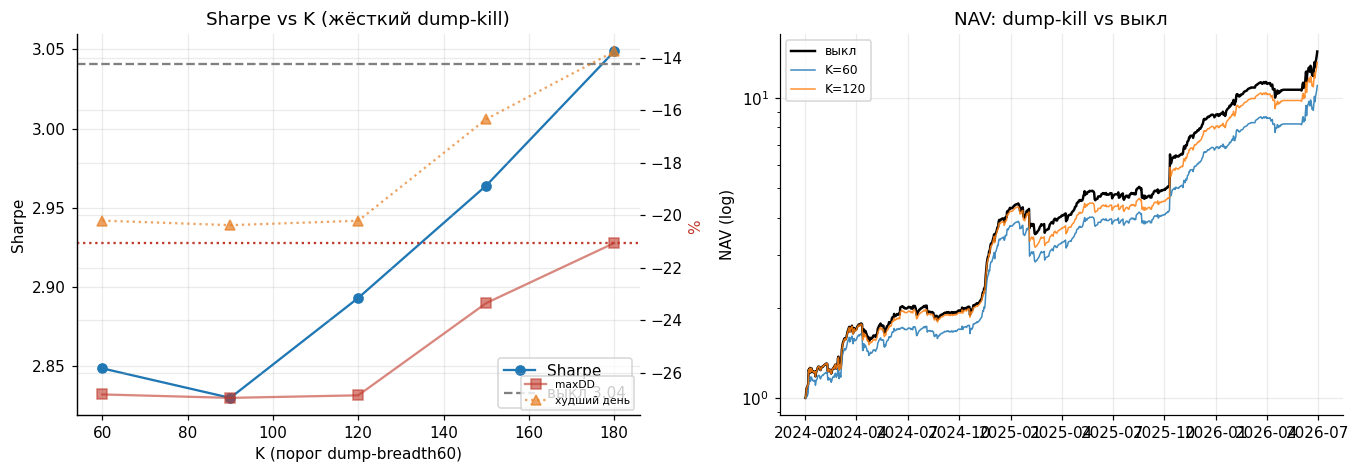

In [7]:
import matplotlib.pyplot as plt
Ks=[60,90,120,150,180]; sh=[]; dd=[]; wd=[]; fin=[]
for K in Ks:
    f,_=kill_dump(BOOK,K); r=q(run_dca(BOOK,ffrac=f)); fin.append(r[0]); sh.append(r[1]); dd.append(r[2]); wd.append(r[3])
fig,ax=plt.subplots(1,2,figsize=(12.5,4.4))
ax[0].plot(Ks,sh,"o-",label="Sharpe"); ax[0].axhline(of[1],ls="--",color="grey",label=f"выкл {of[1]:.2f}")
ax[0].set_xlabel("K (порог dump-breadth60)"); ax[0].set_ylabel("Sharpe"); ax[0].legend(); ax[0].set_title("Sharpe vs K (жёсткий dump-kill)")
ax2=ax[0].twinx(); ax2.plot(Ks,dd,"s-",color="#c0392b",alpha=.6,label="maxDD"); ax2.plot(Ks,wd,"^:",color="#e67e22",alpha=.7,label="худший день"); ax2.axhline(of[2],ls=":",color="#c0392b"); ax2.set_ylabel("% ",color="#c0392b"); ax2.legend(loc="lower right",fontsize=7)
ax[1].plot(Roff["nav"].index,Roff["nav"].values,color="k",lw=1.6,label="выкл")
for K in (60,120):
    f,_=kill_dump(BOOK,K); R=run_dca(BOOK,ffrac=f); ax[1].plot(R["nav"].index,R["nav"].values,lw=1.0,alpha=.85,label=f"K={K}")
ax[1].set_yscale("log"); ax[1].set_ylabel("NAV (log)"); ax[1].legend(fontsize=8); ax[1].set_title("NAV: dump-kill vs выкл")
show("v2_nb03_killswitch")

## Выводы (числа — из ячеек выше)

**Breadth-kill-switch не помогает — ни в одну сторону.**

1. **Гасить ДАМП на высоком дамп-breadth — АКТИВНО ВРЕДИТ.** K=60: рост −16%, Sharpe 3.04→2.85, maxDD
   **−21%→−27%** (глубже!), худший день **−13.8%→−20%** (хуже!). Причина посчитана: заблокированные дампы
   имеют mean **+8…+15%** — это самые прибыльные отскоки (большой вымыв → большой bounce, ровно предупреждение
   dump-nb09). Убирая их, мы теряем profit И снимаем хедж (на дамп-днях дампы гасят убыток пампов) → DD глубже.
   Мягкий вариант (размер ∝ 1/breadth) — тоже монотонно хуже. corr(breadth дня, dump-pnl дня) = **+0.19**:
   breadth НЕ предсказывает плохой исход дампа (если что — слегка положителен).

2. **Гасить ПАМП на высоком дамп-breadth — правильное НАПРАВЛЕНИЕ, но НЕЙТРАЛЬНО.** Заблокированные пампы
   реально убыточны (mean **−3.9%**), т.е. режем лузеров — но портфель не двигается (final/Sharpe/maxDD/
   худший день без изменений). Эти памп-лузеры мелкие (5% размер, обрезаны ёмкостью) → их вклад в NAV
   ничтожен, а просадку делают не они.

3. **Что реально делает просадку.** Худший день −13.8% (2025-02-03) и maxDD −21% — это НЕ breadth-событие:
   даже в этот день дамп-нога была **+7.8%**. Это многодневный риск-офф-дрейф + реализованные закрытия при
   агрессивном сайзинге. Диагностика B: день макс дамп-breadth (2025-10-10) для счёта был ~0 (хедж), а
   corr(breadth, исход) ≈ 0 — стоп/просадка и breadth почти не связаны.

**Итог (совпадает с оригиналом nb12):** breadth-kill-switch — в лучшем случае лёгкий альфа-фильтр (памп-
лузеры), НЕ редуктор просадки; на дамп-ноге он прямо вреден. **Единственная работающая ручка против DD —
РАЗМЕР** (nb00: safe 3/3 даёт maxDD −13.6% против agg −21.1%), а не причинный breadth-фильтр. Оговорка про
оверфит: мы пробовали обе стороны на одних данных; нейтральный памп-kill не даёт in-sample выигрыша →
внедрять нечего. **Хвостовой риск честнее держать сайзингом + катастроф-стопом, чем breadth-фильтром.**